In [1]:
import logging
import warnings
import torch
import torchvision.transforms as transforms
import importlib
import pytorch_lightning
from components import FL_sim
from components.other_utilities import models_to_train
import components.broadcast_components.reporting_utilities
import components.broadcast_components.broadcasting_process.WZ_broadcast
import components.broadcast_components.compressor.rans_coding
import components.other_utilities.datasets

importlib.reload(components.broadcast_components.compressor.rans_coding)
importlib.reload(components.broadcast_components.broadcasting_process.WZ_broadcast)
importlib.reload(components.broadcast_components.reporting_utilities)
# importlib.reload(components.other_utilities.datasets)
importlib.reload(FL_sim)
importlib.reload(models_to_train)

from components.other_utilities.models_to_train import ResNetPLModel
from components.FL_sim import FLSimulator
from components.other_utilities.datasets import FasterSVHN
from components.broadcast_components.broadcasting_process.WZ_broadcast import WZBroadcastProtocol
from components.broadcast_components.reporting_utilities import BroadcastReportingUtilities, plot_stats

torch.set_float32_matmul_precision('high')
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", "LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]")
warnings.filterwarnings("ignore", "You defined a `validation_step` but")
warnings.filterwarnings("ignore", "Starting from v1.9.0, `tensorboardX` has been")
warnings.filterwarnings("ignore", "The number of training batches")
warnings.filterwarnings("ignore", "`Trainer.fit` stopped: ")

In [ ]:
# dataset = [
#     Imagenette(
#         root='./data/Imagenet', split=s,
#         transform=transforms.Compose([
#             transforms.Resize(256),
#             transforms.CenterCrop(224),
#             transforms.ToTensor(),
#             transforms.Normalize(
#                 mean=[0.485, 0.456, 0.406],
#                 std=[0.229, 0.224, 0.225]
#             )
#         ])
#     ) for s in ['train', 'val']]


dataset = [
    FasterSVHN(
        root='./data/SVHN', split=s,
        transform=transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.4377, 0.4438, 0.4728],
                std=[0.1980, 0.2010, 0.1970]
            ),
        ])
    ) for s in ['train', 'test']]

# dataset = [torch.utils.data.Subset(d, list(range(100))) for d in dataset]
# for i in range(10):
#     for d in dataset:
#         d.dataset.labels[i]=i

In [ ]:
k = 5  # Number of workers

# logging_disabled=True
# post_training_report=False

logging_disabled=False
post_training_report=True

batch_size = 7500
# batch_size /= 6 # more batches as samples
# batch_size /= 50 # imagenet
# batch_size /= 3 # resnet 50
batch_size = int(batch_size)

# model.args_for_f_on_grad['save_folder_path'] = \
#     f"experiments/exp_data/gradients_resnet/gradients_resnet_t{i}/"

broadcast_prot_base = WZBroadcastProtocol(k,'RNN', tau=5,
        train_sample_size=100_000, metric_report_flag=False, lr=1e-5, num_planes=3, bins_per_plane=4)
broadcast_prot = BroadcastReportingUtilities(broadcast_prot_base)

model = ResNetPLModel(num_classes=10, resnet_version='resnet18', lr=0.01,
            logging_disabled=logging_disabled, applied_on_grads_before_optim=None)

model.load_state_dict(torch.load('experiments/exp_data/resnet18_svhn.pth', map_location='cpu'))

sim = FLSimulator(
    pl_model=model, num_agents=k, communication_rounds=20, client_epochs_per_round=10,
    batch_size=batch_size, dataset_train=dataset[0], dataset_test=dataset[1],
    aggregation_method='fedavg', non_iid_sampling=False,
)

# pre-training global model before saving it
# sim.do_train_global_model_and_set_local_model(num_epochs=4)
# torch.save(sim.global_model.state_dict(), 'experiments/exp_data/resnet18_svhn.pth')

sim.run_simulation(post_training_report=post_training_report, broadcast_prot=broadcast_prot, pre_training_global_epochs=0, )

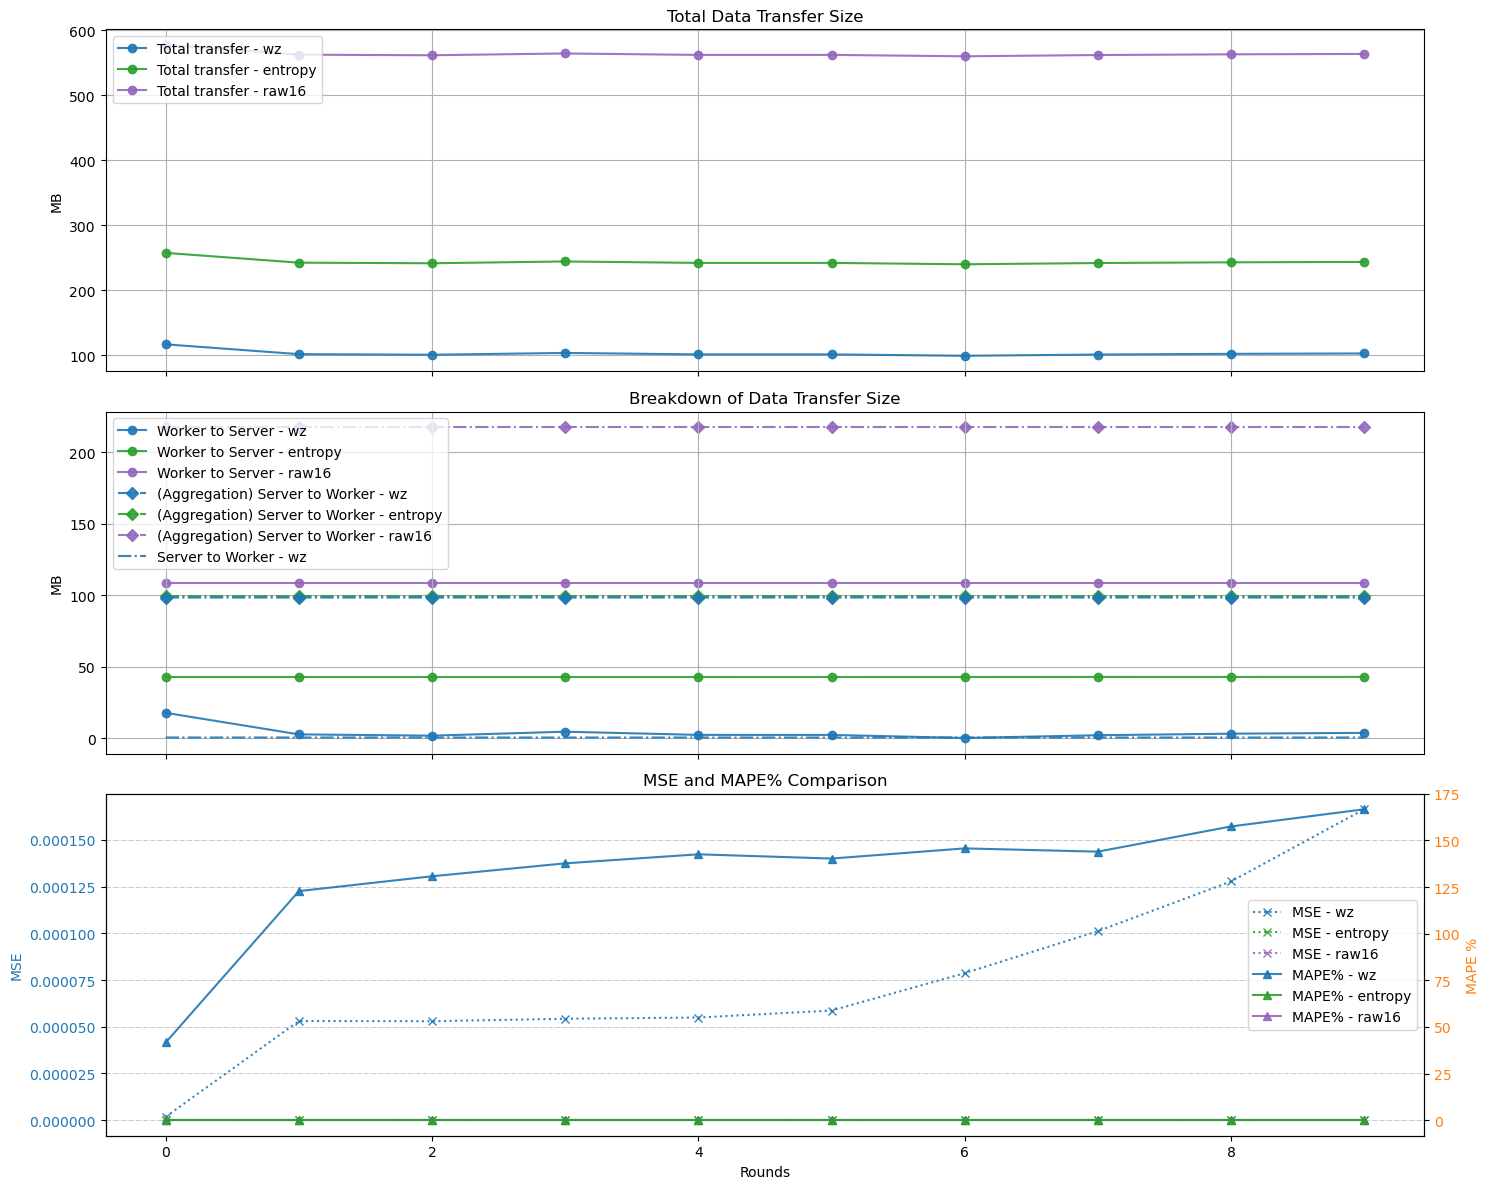

In [152]:
importlib.reload(components.broadcast_components.reporting_utilities)
from components.broadcast_components.reporting_utilities import plot_stats

# stats = broadcast_prot.stats

path_to='experiments/exp_data/Run_stats_first_try/'
with open(path_to+'wz stats report util pickle/100.pkl', 'rb') as f:
    import pickle
    stats = pickle.load(f)
plot_stats(stats)

In [157]:
import numpy as np
import pandas as pd

csv_values = pd.read_csv(path_to+'final_model_stats_(agent and server).csv')
sets = csv_values['sets'].to_list()
ranks = csv_values['rank'].to_list()
loss = csv_values['loss'].to_list()
auc = csv_values['auc'].to_list()

agg_metric={'train':[], 'test':[]}
for i in range(len(csv_values)):
    if ranks[i:i+3]==['ALL', 'ALL', 'ALL'] and sets[i:i+3]==[' test', ' train', ' test',]:
        agg_metric['test'].append([loss[i], auc[i]])
        agg_metric['train'].append([loss[i+1], auc[i+1]])
agg_metric['test'].append([loss[-2], auc[-2]])
agg_metric['train'].append([loss[-1], auc[-1]])
agg_metric = {'train': np.array(agg_metric['train']).T, 'test': np.array(agg_metric['test']).T}
agg_metric = {'train_loss': agg_metric['train'][0], 'test_loss': agg_metric['test'][0],
       'train_auc': agg_metric['train'][1], 'test_auc': agg_metric['test'][1], }
agg_x_range=list(range(len(agg_metric['train_loss'])))

In [178]:
from matplotlib import pyplot as plt
import os

worker_metrics = pd.DataFrame(columns=['index', 'round_id', 'agent_id', 'step', 'train_auc', 'train_loss'])
for round_id in range(20):
    for agent_id in range(5):
        temp=path_to+f'model training metrics/agent_{agent_id}_round_{round_id}/'
        temp+=os.listdir(temp)[-1]+ '/metrics.csv'
        csv_values = pd.read_csv(temp, index_col=0)
        csv_values['round_id'] = round_id
        csv_values['agent_id'] = agent_id
        csv_values['index'] = round_id*20 + csv_values['step']
        worker_metrics = pd.concat([worker_metrics, csv_values], ignore_index=True)
worker_metrics.sort_values(by='index', inplace=True)
worker_metrics['index'] = worker_metrics['index']/worker_metrics['index'].max() * max(agg_x_range)

C:\Users\hosse\AppData\Local\Temp\ipykernel_23220\2665721347.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  worker_metrics = pd.concat([worker_metrics, csv_values], ignore_index=True)


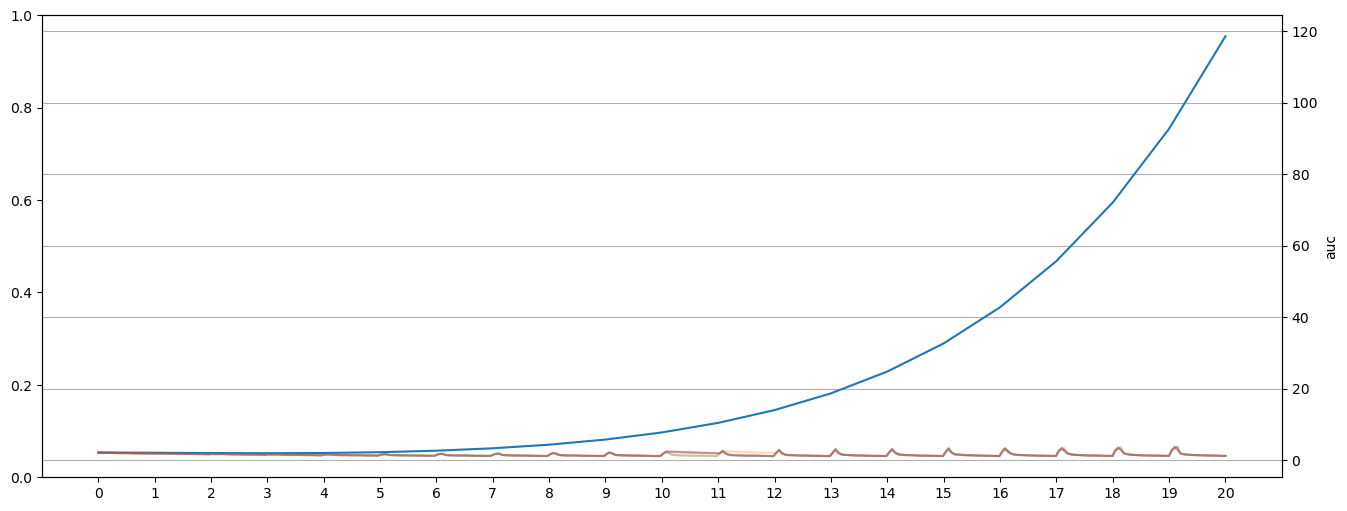

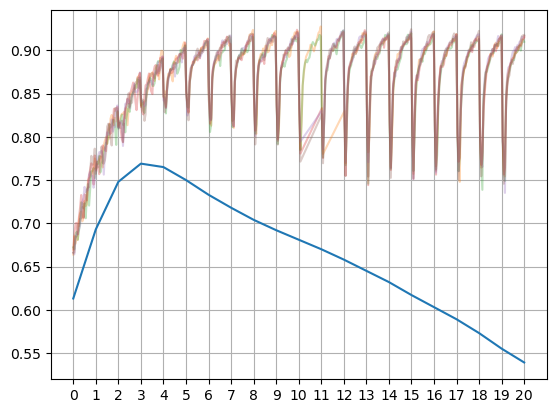

In [214]:
plt.figure(figsize=(16, 6))

temp = plt.twinx()

temp.set_ylabel('loss')
plt.ylabel('auc')
for loss_auc in ['loss', 'auc']:
    ax = {'loss': temp, 'auc': plt}[loss_auc]

    ax.plot(agg_x_range, agg_metric['train_'+loss_auc], label='train '+loss_auc)

    for agent_id in range(5):
        data=worker_metrics[worker_metrics['agent_id'] == agent_id]
        ax.plot(data['index'], data['train_'+loss_auc], label=f'Agent {agent_id}', alpha=0.3)

    plt.xticks(agg_x_range, agg_x_range)
    plt.grid(True)
    plt.show()